# Assignment DSC400 1.2

**Author:** Yisrael Wasserman  
**Date:** September 9, 2026  
**Description:** Basic data analysis of the *Customer Behavior* dataset.

## Getting to know the data

In [1]:
import pandas as pd
import numpy as np 

In [2]:
df = pd.read_csv('customer_behavior.csv')
df.head()

,SessionID,UserID,Platform,SessionDuration,PagesVisited,PurchaseMade,SessionStartTime
0,1,861,Website,257.88,2.0,0,2021-06-01 00:00:00
1,2,1295,MobileApp,344.09,10.0,0,2021-06-01 00:01:00
2,3,1131,Website,889.88,4.0,0,2021-06-01 00:02:00
3,4,1096,Website,617.78,7.0,0,2021-06-01 00:03:00
4,5,1639,Website,1016.97,3.0,0,2021-06-01 00:04:00


Observations on df: 
- Not sure what timeframe SessionDuration is in, best guess is seconds, but I can figure that out later via seeing max and min.
- No other notes. 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SessionID         10000 non-null  int64  
 1   UserID            10000 non-null  int64  
 2   Platform          9809 non-null   str    
 3   SessionDuration   9500 non-null   float64
 4   PagesVisited      9500 non-null   float64
 5   PurchaseMade      10000 non-null  int64  
 6   SessionStartTime  10000 non-null  str    
dtypes: float64(2), int64(3), str(2)
memory usage: 547.0 KB


- Looks like SessionDuration, PagesVisited, and Platform all have null values.
- SessionStartTime is a string instead of a datetime and might need to be converted for visualizations.  

In [4]:
df.describe()

,SessionID,UserID,SessionDuration,PagesVisited,PurchaseMade
count,10000.00000,10000.000000,9500.000000,9500.000000,10000.000000
mean,5000.50000,1502.626900,599.009755,4.988316,0.292200
std,2886.89568,865.021722,426.449757,2.224851,0.454796
min,1.00000,1.000000,2.380000,0.000000,0.000000
25%,2500.75000,762.750000,282.677500,3.000000,0.000000
50%,5000.50000,1493.000000,499.645000,5.000000,0.000000
75%,7500.25000,2250.250000,811.365000,6.000000,1.000000
max,10000.00000,3000.000000,3237.180000,20.000000,1.000000


- The meaning of PagesVisited = 0 is unclear because some of these observations include purchases and positive session durations, so I chose to exclude them from this analysis.
- Based on the quartiles of session duration, I am guessing it is measured in seconds rather than minutes or smaller time segments.
- The maximum number of purchases is only 1, and it appears in only a small sample at the 75th percentile and above.
- PurchaseMade might be a Boolean rather than the number of purchases.  

In [5]:
# I want to see all possible platforms used
print("\nAll possible platforms:")
print(df['Platform'].unique())

/n All possible platforms:
<StringArray>
['Website', 'MobileApp', nan]
Length: 3, dtype: str


## Viewing the missing data

In [6]:
# First I want to view a sample of each missing type df: 

# Columns that contain missing values
missing_type_list = ['SessionDuration', 'PagesVisited', 'Platform']

# Show 5 rows where each column is missing
for missing_type in missing_type_list:
    print(f"\nMissing values in: {missing_type}")
    
    filtered_df = df[df[missing_type].isna()]
    
    print(filtered_df.sample(5))


Missing values in: SessionDuration
      SessionID  UserID   Platform  SessionDuration  PagesVisited  \
419         420     682    Website              NaN           NaN   
6910       6911    2578  MobileApp              NaN           NaN   
3775       3776    1012  MobileApp              NaN           NaN   
2309       2310    1191  MobileApp              NaN           NaN   
519         520    2738    Website              NaN           NaN   

      PurchaseMade     SessionStartTime  
419              1  2021-06-01 06:59:00  
6910             0  2021-06-05 19:10:00  
3775             1  2021-06-03 14:55:00  
2309             1  2021-06-02 14:29:00  
519              1  2021-06-01 08:39:00  

Missing values in: PagesVisited
      SessionID  UserID   Platform  SessionDuration  PagesVisited  \
3478       3479    2022  MobileApp              NaN           NaN   
255         256    2386    Website              NaN           NaN   
1940       1941     353  MobileApp              NaN      

- Nothing sticks out here. I don't see a reason not to drop the missing data.

## Dropping the missing data: 

In [7]:
filtered_df = df.dropna(
    subset=['SessionDuration', 'PagesVisited', 'Platform']
)

filtered_df.info()

<class 'pandas.DataFrame'>
Index: 9319 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SessionID         9319 non-null   int64  
 1   UserID            9319 non-null   int64  
 2   Platform          9319 non-null   str    
 3   SessionDuration   9319 non-null   float64
 4   PagesVisited      9319 non-null   float64
 5   PurchaseMade      9319 non-null   int64  
 6   SessionStartTime  9319 non-null   str    
dtypes: float64(2), int64(3), str(2)
memory usage: 582.4 KB


 - No nan, and we still have 93% of the data

In [8]:
# also dropping any rows wtih PagesVisited = 0 

pages_zero_count = (df['PagesVisited'] == 0).sum()
print(pages_zero_count)

pages_zero = df[df['PagesVisited']==0]

pages_zero.sample(5)

65


,SessionID,UserID,Platform,SessionDuration,PagesVisited,PurchaseMade,SessionStartTime
6430,6431,2031,Website,1076.45,0.0,0,2021-06-05 11:10:00
7099,7100,1927,Website,252.73,0.0,0,2021-06-05 22:19:00
5957,5958,656,Website,386.44,0.0,1,2021-06-05 03:17:00
5722,5723,809,Website,473.66,0.0,0,2021-06-04 23:22:00
4409,4410,202,MobileApp,641.05,0.0,0,2021-06-04 01:29:00


- I am not sure how PagesVisited can be 0 when PurchaseMade is greater than 0. The way PagesVisited is calculated may differ from how page count is recorded.
- A similar issue occurs when SessionDuration is greater than 0 while PagesVisited is 0. 

In [9]:
# Count purchases made where PagesVisited == 0
total_purchases_with_zero_pages = (pages_zero['PurchaseMade'] > 0).sum()
total_purchases = (df['PurchaseMade'] >0).sum()
print(f'Total purchases with Zero pages visited: {total_purchases_with_zero_pages}')
print(f'Total purchases overall: {total_purchases}')

Total purchases with Zero pages visited: 19
Total purchases with >0 pages visited: 2922


- Because the meaning of zero pages visited is unclear and there are only 19 purchase cases among these observations, I chose to exclude them from this analysis.

In [10]:
# back to filtered_df dropping any pages_visted = 0 
filtered_df = filtered_df[filtered_df['PagesVisited'] != 0]

print(filtered_df['PagesVisited'].min()) # see if it worked

1.0


## Feature Engineering:


In [11]:
# create average page duration, the average time spent on each page:  

filtered_df['Avg_page_dur'] = (filtered_df['SessionDuration'] / filtered_df['PagesVisited'])
filtered_df.head()

,SessionID,UserID,Platform,SessionDuration,PagesVisited,PurchaseMade,SessionStartTime,Avg_page_dur
0,1,861,Website,257.88,2.0,0,2021-06-01 00:00:00,128.940000
1,2,1295,MobileApp,344.09,10.0,0,2021-06-01 00:01:00,34.409000
2,3,1131,Website,889.88,4.0,0,2021-06-01 00:02:00,222.470000
3,4,1096,Website,617.78,7.0,0,2021-06-01 00:03:00,88.254286
4,5,1639,Website,1016.97,3.0,0,2021-06-01 00:04:00,338.990000


## Aggregation: 

In [12]:
# See average session duration by Platform 

filtered_df.groupby('Platform')['SessionDuration'].mean()

Platform
MobileApp    595.863288
Website      600.956546
Name: SessionDuration, dtype: float64

In [13]:
# see average pages visited by platform 

filtered_df.groupby('Platform')['PagesVisited'].mean()

Platform
MobileApp    5.000648
Website      4.977166
Name: PagesVisited, dtype: float64

# Visualization

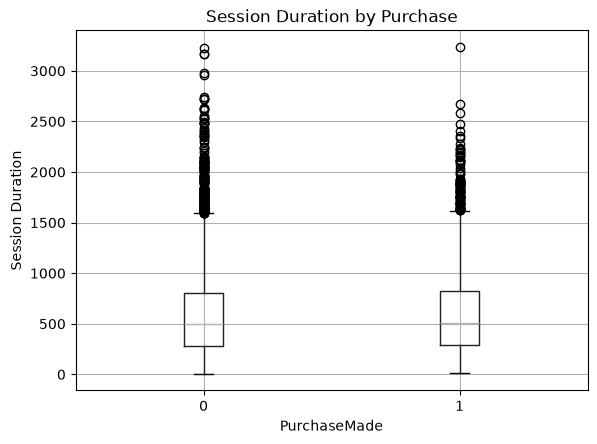

In [14]:
# Vizualize how long average session is by purache made:  
import matplotlib.pyplot as plt


filtered_df.boxplot(
    column='SessionDuration',
    by='PurchaseMade'
)

plt.ylabel('Session Duration')
plt.title('Session Duration by Purchase')
plt.suptitle('')
plt.show()